In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 01b — Funding and open-interest ablation

Untuned CatBoost compares price/order-flow, seven added positioning features, and a 41-day-shifted positioning placebo on identical rows at DZ55/60/65/75.
Both blocked CV and weekly 180-day walk-forward use development data through June 2025, ungated one-bar trades and 10 bps round-trip costs.

Net differences measure total economic change; per-trade expectancy separates trade quality from reduced activity, while the paired Diebold–Mariano statistic uses a 96-bar Newey–West lag.

In [2]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from features.build import build_dataset
from evaluation.splits import BlockingTimeSeriesSplit
from evaluation.economics import strategy_returns, economics_summary, diebold_mariano
from experiments.oof_cache import oof_cached
from experiments.run_positioning_ablation import PLACEBO_SHIFT_BARS, cache_path as wf_cache

cfg = yaml.safe_load((CODE_ROOT / "configs" / "default.yaml").read_text())
SPLIT = cfg["split"]
FEE_BPS = float(cfg["taker_fee_bps"])
WIDTHS = [55, 60, 65, 75]
DM_LAG = 96                                   # one day of M15 bars

working = pd.read_parquet(CODE_ROOT / cfg["paths"]["working_parquet"])
df = working.loc["2024-01-01":"2025-06-30"]           # development window
fwd_all = df["close"].pct_change().shift(-1)          # next-bar return

pos = pd.read_parquet(CODE_ROOT / "data" / "btcusdt_positioning_m15_2024_2026.parquet")
pos_dev = pos.reindex(df.index)
placebo_block = pd.DataFrame(np.roll(pos_dev.to_numpy(), PLACEBO_SHIFT_BARS, axis=0),
                             index=pos_dev.index, columns=pos_dev.columns)

dfp = df.join(pos_dev)                # real positioning
dfq = df.join(placebo_block)          # same columns, 41 days out of alignment

print(f"dev bars {len(df):,} ({df.index[0]:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d}) | "
      f"positioning coverage {pos_dev.notna().all(axis=1).mean():.1%} | "
      f"fee {FEE_BPS:g} bps/side | no gate")

dev bars 52,512 (2024-01-01 -> 2025-06-30) | positioning coverage 100.0% | fee 5 bps/side | no gate


## 1. Blocked cross-validation

The lagged placebo tests whether extra columns alone account for the apparent improvement; it is a diagnostic control, not proof of causation.

In [3]:
from IPython.display import Markdown
def econ(pred):
    ret = strategy_returns(pred, fwd_all.reindex(pred.index), FEE_BPS)
    s = economics_summary(ret, pred)
    s["exp_bps"] = s["net_return_sum"] / max(s["trade_count"], 1) * 1e4
    return ret, s


cv = {}
for thr in WIDTHS:
    frames = {"base": build_dataset(dfp, threshold_bps=thr, horizon=1),
              "pos": build_dataset(dfp, threshold_bps=thr, horizon=1, positioning=True),
              "placebo": build_dataset(dfq, threshold_bps=thr, horizon=1, positioning=True)}
    common = frames["base"][0].index
    for X, _ in frames.values():
        common = common.intersection(X.index)
    splitter = BlockingTimeSeriesSplit(n_splits=SPLIT["n_splits"],
                                       train_frac=SPLIT["train_frac"],
                                       embargo=SPLIT["embargo_bars"])
    for arm, (X, y) in frames.items():
        pred, _, _ = oof_cached(X.loc[common], y.loc[common], None, splitter)
        ret, s = econ(pred)
        cv[(thr, arm)] = {"ret": ret, "s": s}


def monthly(series):
    """Calendar-month sums of a (possibly tz-aware) return series."""
    idx = series.index.tz_convert(None) if series.index.tz is not None else series.index
    return series.groupby(idx.to_period("M")).sum()


def protocol_table(store):
    """base vs +pos economics, their deltas, and both paired DM tests."""
    rows = []
    for thr in WIDTHS:
        if (thr, "base") not in store or (thr, "pos") not in store:
            continue
        b, p = store[(thr, "base")]["s"], store[(thr, "pos")]["s"]
        dm = diebold_mariano(store[(thr, "base")]["ret"], store[(thr, "pos")]["ret"],
                             lag=DM_LAG)
        row = {"dz": thr,
               "Sortino base": b["sortino"], "Sortino +pos": p["sortino"],
               "Sharpe base": b["sharpe"], "Sharpe +pos": p["sharpe"],
               "net base": b["net_return_sum"], "net +pos": p["net_return_sum"],
               "trades base": b["trade_count"], "trades +pos": p["trade_count"],
               "exp/trade base": b["exp_bps"], "exp/trade +pos": p["exp_bps"],
               "Δ net": p["net_return_sum"] - b["net_return_sum"],
               "Δ exp/trade": p["exp_bps"] - b["exp_bps"],
               "DM vs base": dm["dm_stat"]}
        if (thr, "placebo") in store:
            q = store[(thr, "placebo")]["s"]
            dmq = diebold_mariano(store[(thr, "placebo")]["ret"],
                                  store[(thr, "pos")]["ret"], lag=DM_LAG)
            m = monthly(store[(thr, "pos")]["ret"] - store[(thr, "placebo")]["ret"])
            row.update({
                "trades placebo": q["trade_count"],
                "Δ net vs placebo": p["net_return_sum"] - q["net_return_sum"],
                "Δ exp/trade vs placebo": p["exp_bps"] - q["exp_bps"],
                "DM vs placebo": dmq["dm_stat"],
                "months + vs placebo": f"{int((m > 0).sum())}/{len(m)}"})
        rows.append(row)
    return pd.DataFrame(rows).set_index("dz")


cv_table = protocol_table(cv)
display(Markdown('Method: Five blocked tests compare base, positioning and its 41-day-shifted placebo on identical rows after costs.'))
display(cv_table.round(4))
display(Markdown("Part of positioning's apparent benefit is also present in the placebo."))

Method: Five blocked tests compare base, positioning and its 41-day-shifted placebo on identical rows after costs.

,Sortino base,Sortino +pos,Sharpe base,Sharpe +pos,net base,net +pos,trades base,trades +pos,exp/trade base,exp/trade +pos,Δ net,Δ exp/trade,DM vs base,trades placebo,Δ net vs placebo,Δ exp/trade vs placebo,DM vs placebo,months + vs placebo
dz,,,,,,,,,,,,,,,,,,
55,-10.3554,-4.4878,-7.9489,-3.2494,-0.9117,-0.3209,1323,878,-6.8908,-3.6554,0.5907,3.2354,2.8195,927,0.2059,2.0279,1.1852,5/7
60,-10.8300,-5.7013,-8.6375,-4.3498,-0.9044,-0.3895,1041,716,-8.6880,-5.4403,0.5149,3.2476,2.8225,669,0.1772,3.0314,1.2751,5/7
65,-7.5685,-2.2909,-5.9561,-1.6375,-0.5681,-0.1149,848,480,-6.6995,-2.3940,0.4532,4.3054,2.8721,471,0.3690,7.8796,2.6571,5/7
75,-6.9660,-1.9695,-5.7560,-1.4502,-0.4353,-0.0771,517,267,-8.4188,-2.8871,0.3582,5.5317,2.3267,275,0.2063,7.4180,2.0334,5/7


Part of positioning's apparent benefit is also present in the placebo.

## 2. Weekly walk-forward

Each week from July 2024 to June 2025 is predicted using only the preceding 180 days.

In [4]:
from IPython.display import Markdown
MODEL = "catboost_balanced"
wf, missing = {}, []
for thr in WIDTHS:
    for arm in ("base", "pos", "placebo"):
        path = wf_cache(arm, thr)
        if not path.exists():
            missing.append(path.name)
            continue
        d = pd.read_parquet(path)
        d.index = pd.to_datetime(d.index, utc=True)
        pred = d[f"{MODEL}_pred"].astype(int)
        ret = strategy_returns(pred, d["forward_return"], FEE_BPS)
        s = economics_summary(ret, pred)
        s["exp_bps"] = s["net_return_sum"] / max(s["trade_count"], 1) * 1e4
        wf[(thr, arm)] = {"ret": ret, "s": s}

if missing:
    print("missing caches — run `python -m experiments.run_positioning_ablation`:")
    print("  " + ", ".join(missing))

wf_table = protocol_table(wf) if wf else pd.DataFrame()
if not wf_table.empty:
    print("Protocol B — walk-forward, weekly retrain, 180-day history, ungated:")
    display(Markdown('Method: Weekly predictions use a trailing 180-day fit from July 2024 through June 2025 with unchanged costs.'))
    display(wf_table.round(4))
    display(Markdown('Positioning improves total Net without establishing positive per-trade expectancy.'))

Protocol B — walk-forward, weekly retrain, 180-day history, ungated:


Method: Weekly predictions use a trailing 180-day fit from July 2024 through June 2025 with unchanged costs.

,Sortino base,Sortino +pos,Sharpe base,Sharpe +pos,net base,net +pos,trades base,trades +pos,exp/trade base,exp/trade +pos,Δ net,Δ exp/trade,DM vs base,trades placebo,Δ net vs placebo,Δ exp/trade vs placebo,DM vs placebo,months + vs placebo
dz,,,,,,,,,,,,,,,,,,
55,-11.9976,-9.3699,-9.0102,-6.8001,-3.2065,-2.3074,5383,4544,-5.9567,-5.0780,0.8991,0.8787,2.5655,4434,0.1161,0.3877,0.3556,6/12
60,-7.8774,-7.4678,-5.6822,-5.3823,-1.9071,-1.6864,4546,3660,-4.1951,-4.6076,0.2207,-0.4125,0.6301,3668,0.5551,1.5033,1.6218,7/12
65,-9.1933,-6.2430,-6.8892,-4.4462,-2.1999,-1.3095,3912,3072,-5.6236,-4.2628,0.8904,1.3608,2.3809,3092,0.3554,1.1218,1.0442,7/12
75,-7.4674,-4.2179,-5.4994,-2.9717,-1.5172,-0.7101,2852,2044,-5.3198,-3.4740,0.8071,1.8458,2.2348,1956,0.4816,2.6185,1.8611,6/12


Positioning improves total Net without establishing positive per-trade expectancy.

## 3. Paired comparison

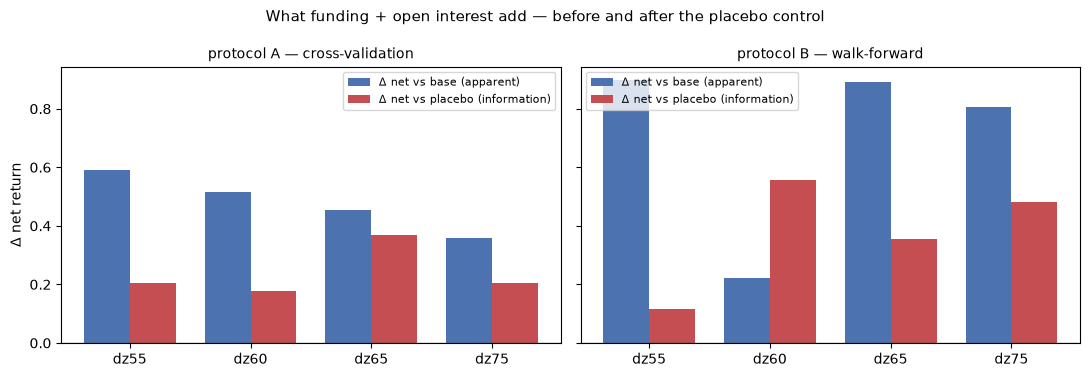

Method: Paired differences summarise the base and placebo contrasts separately for the two protocols.

,A: Δ net vs base,A: Δ net vs placebo,A: Δ exp/trade vs placebo,A: DM vs placebo,A: months +,B: Δ net vs base,B: Δ net vs placebo,B: Δ exp/trade vs placebo,B: DM vs placebo,B: months +
dz,,,,,,,,,,
55,0.591,0.206,2.028,1.185,5/7,0.899,0.116,0.388,0.356,6/12
60,0.515,0.177,3.031,1.275,5/7,0.221,0.555,1.503,1.622,7/12
65,0.453,0.369,7.880,2.657,5/7,0.890,0.355,1.122,1.044,7/12
75,0.358,0.206,7.418,2.033,5/7,0.807,0.482,2.618,1.861,6/12


The gain surviving the placebo is smaller than the unadjusted gain.

In [5]:
from IPython.display import Markdown
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x, w = np.arange(len(WIDTHS)), 0.38
for ax, (name, t) in zip(axes, [("protocol A — cross-validation", cv_table),
                                ("protocol B — walk-forward", wf_table)]):
    if t.empty:
        ax.set_visible(False)
        continue
    ax.bar(x - w / 2, [t["Δ net"].get(k, np.nan) for k in WIDTHS], w,
           color="#4c72b0", label="Δ net vs base (apparent)")
    ax.bar(x + w / 2, [t["Δ net vs placebo"].get(k, np.nan) for k in WIDTHS], w,
           color="#c44e52", label="Δ net vs placebo (information)")
    ax.axhline(0, color="#444", lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels([f"dz{k}" for k in WIDTHS])
    ax.set_title(name, fontsize=10); ax.legend(fontsize=8)
axes[0].set_ylabel("Δ net return")
fig.suptitle("What funding + open interest add — before and after the placebo control",
             fontsize=11)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "A: Δ net vs base": cv_table["Δ net"],
    "A: Δ net vs placebo": cv_table["Δ net vs placebo"],
    "A: Δ exp/trade vs placebo": cv_table["Δ exp/trade vs placebo"],
    "A: DM vs placebo": cv_table["DM vs placebo"],
    "A: months +": cv_table["months + vs placebo"],
})
if not wf_table.empty:
    summary["B: Δ net vs base"] = wf_table["Δ net"]
    summary["B: Δ net vs placebo"] = wf_table["Δ net vs placebo"]
    summary["B: Δ exp/trade vs placebo"] = wf_table["Δ exp/trade vs placebo"]
    summary["B: DM vs placebo"] = wf_table["DM vs placebo"]
    summary["B: months +"] = wf_table["months + vs placebo"]
display(Markdown('Method: Paired differences summarise the base and placebo contrasts separately for the two protocols.'))
display(summary.round(3))
display(Markdown('The gain surviving the placebo is smaller than the unadjusted gain.'))

for name, t in (("A (cross-validation)", cv_table), ("B (walk-forward)", wf_table)):
    if t.empty:
        continue
    share = t["Δ net vs placebo"].mean() / t["Δ net"].mean() if t["Δ net"].mean() else np.nan
    mo = [tuple(int(v) for v in s.split("/")) for s in t["months + vs placebo"]]

## Conclusion

Positioning improves the control under both protocols, but the placebo explains part of the gain and per-trade returns remain negative after costs.